In [4]:
from google.colab import files

uploaded = files.upload()

Saving shipping_data.csv to shipping_data.csv
Saving vendor_contracts.csv to vendor_contracts.csv


In [5]:
import pandas as pd

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Day 2 CSV loaded successfully!")
print("File:", filename)
print("Shape:", df.shape)

df.head()

Day 2 CSV loaded successfully!
File: shipping_data.csv
Shape: (500, 12)


,Shipment_ID,Vendor,Origin,Destination,Shipping_Mode,Distance_km,Weather,Traffic,Planned_Delivery_Days,Actual_Delivery_Days,Delay_Days,Delayed
0,SHP0001,Beta Suppliers,Chennai,Mumbai,Rail,964,Clear,Low,2,2,0,0
1,SHP0002,Omega Supplies,Chennai,Coimbatore,Rail,1002,Rain,Low,3,5,2,1
2,SHP0003,Prime Logistics,Mumbai,Chennai,Rail,1781,Clear,Low,3,3,0,0
3,SHP0004,Beta Suppliers,Coimbatore,Pune,Road,1520,Storm,Medium,3,6,3,1
4,SHP0005,Omega Supplies,Coimbatore,Mumbai,Air,2414,Clear,Low,5,5,0,0


In [6]:
print("Columns:")
print(df.columns.tolist())

print("\nNumber of shipments:", df["Shipment_ID"].nunique())
print("Number of vendors:", df["Vendor"].nunique())

print("\nVendors:")
print(df["Vendor"].unique())

Columns:
['Shipment_ID', 'Vendor', 'Origin', 'Destination', 'Shipping_Mode', 'Distance_km', 'Weather', 'Traffic', 'Planned_Delivery_Days', 'Actual_Delivery_Days', 'Delay_Days', 'Delayed']

Number of shipments: 500
Number of vendors: 8

Vendors:
['Beta Suppliers' 'Omega Supplies' 'Prime Logistics' 'Epsilon Exports'
 'Delta Traders' 'Zeta Manufacturing' 'Gamma Industries' 'Alpha Logistics']


In [7]:
df[[
    "Shipment_ID",
    "Vendor",
    "Planned_Delivery_Days",
    "Actual_Delivery_Days",
    "Delay_Days",
    "Delayed"
]].head(10)

,Shipment_ID,Vendor,Planned_Delivery_Days,Actual_Delivery_Days,Delay_Days,Delayed
0,SHP0001,Beta Suppliers,2,2,0,0
1,SHP0002,Omega Supplies,3,5,2,1
2,SHP0003,Prime Logistics,3,3,0,0
3,SHP0004,Beta Suppliers,3,6,3,1
4,SHP0005,Omega Supplies,5,5,0,0
5,SHP0006,Epsilon Exports,4,4,0,0
6,SHP0007,Delta Traders,6,7,1,1
7,SHP0008,Zeta Manufacturing,2,3,1,1
8,SHP0009,Delta Traders,1,3,2,1
9,SHP0010,Omega Supplies,2,2,0,0


In [8]:
contracts = pd.DataFrame({
    "Vendor": [
        "Alpha Logistics",
        "Beta Suppliers",
        "Gamma Industries",
        "Delta Traders",
        "Epsilon Exports",
        "Zeta Manufacturing",
        "Omega Supplies",
        "Prime Logistics"
    ],

    "Contract_Delivery_Days": [
        7, 10, 8, 12, 9, 11, 10, 7
    ],

    "Delay_Notification_Hours": [
        24, 48, 24, 72, 24, 48, 24, 24
    ],

    "Penalty_For_Delay": [
        "Yes", "Yes", "No", "Yes",
        "Yes", "Yes", "No", "Yes"
    ],

    "Payment_Period_Days": [
        30, 45, 30, 60, 30, 45, 30, 30
    ],

    "Termination_Notice_Days": [
        30, 30, 15, 60, 30, 30, 15, 30
    ]
})

contracts

,Vendor,Contract_Delivery_Days,Delay_Notification_Hours,Penalty_For_Delay,Payment_Period_Days,Termination_Notice_Days
0,Alpha Logistics,7,24,Yes,30,30
1,Beta Suppliers,10,48,Yes,45,30
2,Gamma Industries,8,24,No,30,15
3,Delta Traders,12,72,Yes,60,60
4,Epsilon Exports,9,24,Yes,30,30
5,Zeta Manufacturing,11,48,Yes,45,30
6,Omega Supplies,10,24,No,30,15
7,Prime Logistics,7,24,Yes,30,30


In [9]:
print("Vendors in shipment data:")
print(sorted(df["Vendor"].unique()))

print("\nVendors in contract data:")
print(sorted(contracts["Vendor"].unique()))

Vendors in shipment data:
['Alpha Logistics', 'Beta Suppliers', 'Delta Traders', 'Epsilon Exports', 'Gamma Industries', 'Omega Supplies', 'Prime Logistics', 'Zeta Manufacturing']

Vendors in contract data:
['Alpha Logistics', 'Beta Suppliers', 'Delta Traders', 'Epsilon Exports', 'Gamma Industries', 'Omega Supplies', 'Prime Logistics', 'Zeta Manufacturing']


In [10]:
connected_df = df.merge(
    contracts,
    on="Vendor",
    how="left"
)

print("Shipment and contract information connected successfully!")

print("Shape:", connected_df.shape)

connected_df.head()

Shipment and contract information connected successfully!
Shape: (500, 17)


,Shipment_ID,Vendor,Origin,Destination,Shipping_Mode,Distance_km,Weather,Traffic,Planned_Delivery_Days,Actual_Delivery_Days,Delay_Days,Delayed,Contract_Delivery_Days,Delay_Notification_Hours,Penalty_For_Delay,Payment_Period_Days,Termination_Notice_Days
0,SHP0001,Beta Suppliers,Chennai,Mumbai,Rail,964,Clear,Low,2,2,0,0,10,48,Yes,45,30
1,SHP0002,Omega Supplies,Chennai,Coimbatore,Rail,1002,Rain,Low,3,5,2,1,10,24,No,30,15
2,SHP0003,Prime Logistics,Mumbai,Chennai,Rail,1781,Clear,Low,3,3,0,0,7,24,Yes,30,30
3,SHP0004,Beta Suppliers,Coimbatore,Pune,Road,1520,Storm,Medium,3,6,3,1,10,48,Yes,45,30
4,SHP0005,Omega Supplies,Coimbatore,Mumbai,Air,2414,Clear,Low,5,5,0,0,10,24,No,30,15


In [11]:
connected_df[[
    "Shipment_ID",
    "Vendor",
    "Delay_Days",
    "Contract_Delivery_Days",
    "Delay_Notification_Hours",
    "Penalty_For_Delay"
]].head(15)

,Shipment_ID,Vendor,Delay_Days,Contract_Delivery_Days,Delay_Notification_Hours,Penalty_For_Delay
0,SHP0001,Beta Suppliers,0,10,48,Yes
1,SHP0002,Omega Supplies,2,10,24,No
2,SHP0003,Prime Logistics,0,7,24,Yes
3,SHP0004,Beta Suppliers,3,10,48,Yes
4,SHP0005,Omega Supplies,0,10,24,No
5,SHP0006,Epsilon Exports,0,9,24,Yes
6,SHP0007,Delta Traders,1,12,72,Yes
7,SHP0008,Zeta Manufacturing,1,11,48,Yes
8,SHP0009,Delta Traders,2,12,72,Yes
9,SHP0010,Omega Supplies,0,10,24,No


In [12]:
connected_df["Delivery_Compliance"] = connected_df.apply(
    lambda row: "Compliant"
    if row["Actual_Delivery_Days"] <= row["Contract_Delivery_Days"]
    else "Violation",
    axis=1
)

connected_df[[
    "Shipment_ID",
    "Vendor",
    "Actual_Delivery_Days",
    "Contract_Delivery_Days",
    "Delivery_Compliance"
]].head(15)

,Shipment_ID,Vendor,Actual_Delivery_Days,Contract_Delivery_Days,Delivery_Compliance
0,SHP0001,Beta Suppliers,2,10,Compliant
1,SHP0002,Omega Supplies,5,10,Compliant
2,SHP0003,Prime Logistics,3,7,Compliant
3,SHP0004,Beta Suppliers,6,10,Compliant
4,SHP0005,Omega Supplies,5,10,Compliant
5,SHP0006,Epsilon Exports,4,9,Compliant
6,SHP0007,Delta Traders,7,12,Compliant
7,SHP0008,Zeta Manufacturing,3,11,Compliant
8,SHP0009,Delta Traders,3,12,Compliant
9,SHP0010,Omega Supplies,2,10,Compliant


In [13]:
connected_df["Penalty_Applicable"] = connected_df.apply(
    lambda row: "Yes"
    if row["Delay_Days"] > 0 and row["Penalty_For_Delay"] == "Yes"
    else "No",
    axis=1
)

connected_df[[
    "Shipment_ID",
    "Vendor",
    "Delay_Days",
    "Penalty_For_Delay",
    "Penalty_Applicable"
]].head(15)

,Shipment_ID,Vendor,Delay_Days,Penalty_For_Delay,Penalty_Applicable
0,SHP0001,Beta Suppliers,0,Yes,No
1,SHP0002,Omega Supplies,2,No,No
2,SHP0003,Prime Logistics,0,Yes,No
3,SHP0004,Beta Suppliers,3,Yes,Yes
4,SHP0005,Omega Supplies,0,No,No
5,SHP0006,Epsilon Exports,0,Yes,No
6,SHP0007,Delta Traders,1,Yes,Yes
7,SHP0008,Zeta Manufacturing,1,Yes,Yes
8,SHP0009,Delta Traders,2,Yes,Yes
9,SHP0010,Omega Supplies,0,No,No


In [14]:
connected_df["Notification_Required"] = connected_df.apply(
    lambda row: "Yes"
    if row["Delay_Days"] > 0
    else "No",
    axis=1
)

connected_df[[
    "Shipment_ID",
    "Vendor",
    "Delay_Days",
    "Delay_Notification_Hours",
    "Notification_Required"
]].head(15)

,Shipment_ID,Vendor,Delay_Days,Delay_Notification_Hours,Notification_Required
0,SHP0001,Beta Suppliers,0,48,No
1,SHP0002,Omega Supplies,2,24,Yes
2,SHP0003,Prime Logistics,0,24,No
3,SHP0004,Beta Suppliers,3,48,Yes
4,SHP0005,Omega Supplies,0,24,No
5,SHP0006,Epsilon Exports,0,24,No
6,SHP0007,Delta Traders,1,72,Yes
7,SHP0008,Zeta Manufacturing,1,48,Yes
8,SHP0009,Delta Traders,2,72,Yes
9,SHP0010,Omega Supplies,0,24,No


In [15]:
def calculate_contract_risk(row):
    if row["Delivery_Compliance"] == "Violation" and row["Penalty_Applicable"] == "Yes":
        return "High Risk"

    elif row["Delivery_Compliance"] == "Violation":
        return "Medium Risk"

    else:
        return "Low Risk"


connected_df["Contract_Risk"] = connected_df.apply(
    calculate_contract_risk,
    axis=1
)

connected_df[[
    "Shipment_ID",
    "Vendor",
    "Delay_Days",
    "Delivery_Compliance",
    "Penalty_Applicable",
    "Contract_Risk"
]].head(20)

,Shipment_ID,Vendor,Delay_Days,Delivery_Compliance,Penalty_Applicable,Contract_Risk
0,SHP0001,Beta Suppliers,0,Compliant,No,Low Risk
1,SHP0002,Omega Supplies,2,Compliant,No,Low Risk
2,SHP0003,Prime Logistics,0,Compliant,No,Low Risk
3,SHP0004,Beta Suppliers,3,Compliant,Yes,Low Risk
4,SHP0005,Omega Supplies,0,Compliant,No,Low Risk
5,SHP0006,Epsilon Exports,0,Compliant,No,Low Risk
6,SHP0007,Delta Traders,1,Compliant,Yes,Low Risk
7,SHP0008,Zeta Manufacturing,1,Compliant,Yes,Low Risk
8,SHP0009,Delta Traders,2,Compliant,Yes,Low Risk
9,SHP0010,Omega Supplies,0,Compliant,No,Low Risk


In [16]:
final_output = connected_df[[
    "Shipment_ID",
    "Vendor",
    "Planned_Delivery_Days",
    "Actual_Delivery_Days",
    "Delay_Days",
    "Delayed",
    "Contract_Delivery_Days",
    "Delay_Notification_Hours",
    "Penalty_For_Delay",
    "Delivery_Compliance",
    "Penalty_Applicable",
    "Contract_Risk"
]]

final_output.head(20)

,Shipment_ID,Vendor,Planned_Delivery_Days,Actual_Delivery_Days,Delay_Days,Delayed,Contract_Delivery_Days,Delay_Notification_Hours,Penalty_For_Delay,Delivery_Compliance,Penalty_Applicable,Contract_Risk
0,SHP0001,Beta Suppliers,2,2,0,0,10,48,Yes,Compliant,No,Low Risk
1,SHP0002,Omega Supplies,3,5,2,1,10,24,No,Compliant,No,Low Risk
2,SHP0003,Prime Logistics,3,3,0,0,7,24,Yes,Compliant,No,Low Risk
3,SHP0004,Beta Suppliers,3,6,3,1,10,48,Yes,Compliant,Yes,Low Risk
4,SHP0005,Omega Supplies,5,5,0,0,10,24,No,Compliant,No,Low Risk
5,SHP0006,Epsilon Exports,4,4,0,0,9,24,Yes,Compliant,No,Low Risk
6,SHP0007,Delta Traders,6,7,1,1,12,72,Yes,Compliant,Yes,Low Risk
7,SHP0008,Zeta Manufacturing,2,3,1,1,11,48,Yes,Compliant,Yes,Low Risk
8,SHP0009,Delta Traders,1,3,2,1,12,72,Yes,Compliant,Yes,Low Risk
9,SHP0010,Omega Supplies,2,2,0,0,10,24,No,Compliant,No,Low Risk


In [17]:
print("Contract Risk Summary:")
print(final_output["Contract_Risk"].value_counts())


Contract Risk Summary:
Contract_Risk
Low Risk       462
High Risk       27
Medium Risk     11
Name: count, dtype: int64


In [18]:
final_output.to_csv(
    "day3_delay_contract_analysis.csv",
    index=False
)

print("Day 3 analysis saved successfully!")




Day 3 analysis saved successfully!


In [19]:
import matplotlib.pyplot as plt




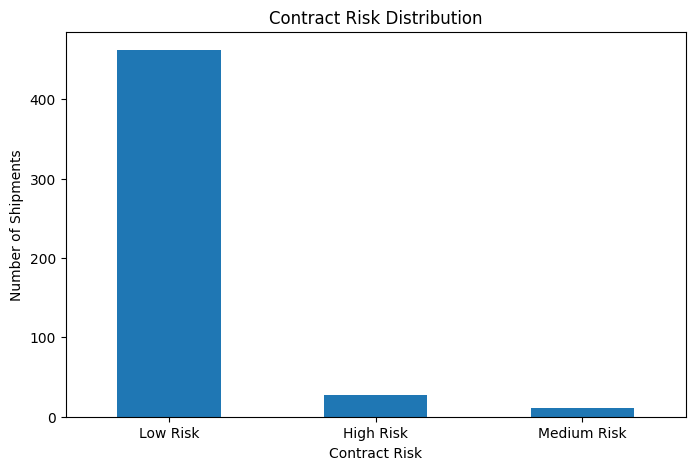

In [20]:
risk_counts = final_output["Contract_Risk"].value_counts()

plt.figure(figsize=(8, 5))
risk_counts.plot(kind="bar")

plt.title("Contract Risk Distribution")
plt.xlabel("Contract Risk")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=0)
plt.show()


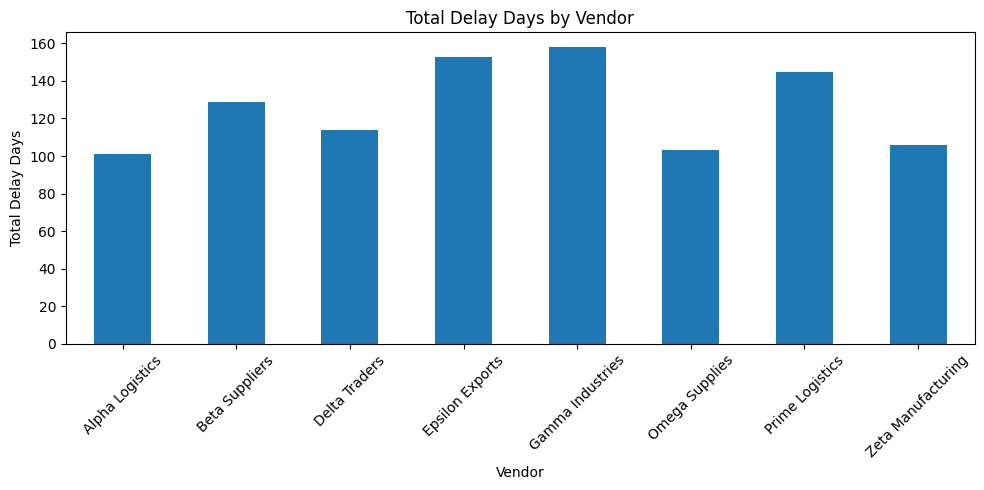

In [21]:
vendor_delay = final_output.groupby("Vendor")["Delay_Days"].sum()

plt.figure(figsize=(10, 5))
vendor_delay.plot(kind="bar")

plt.title("Total Delay Days by Vendor")
plt.xlabel("Vendor")
plt.ylabel("Total Delay Days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

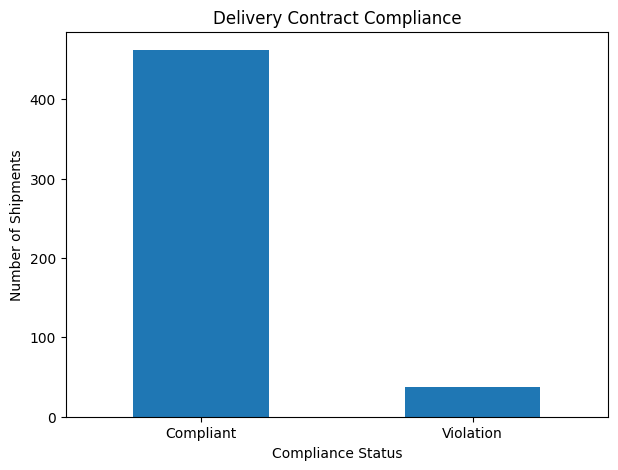

In [22]:
compliance_counts = final_output["Delivery_Compliance"].value_counts()

plt.figure(figsize=(7, 5))
compliance_counts.plot(kind="bar")

plt.title("Delivery Contract Compliance")
plt.xlabel("Compliance Status")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=0)
plt.show()

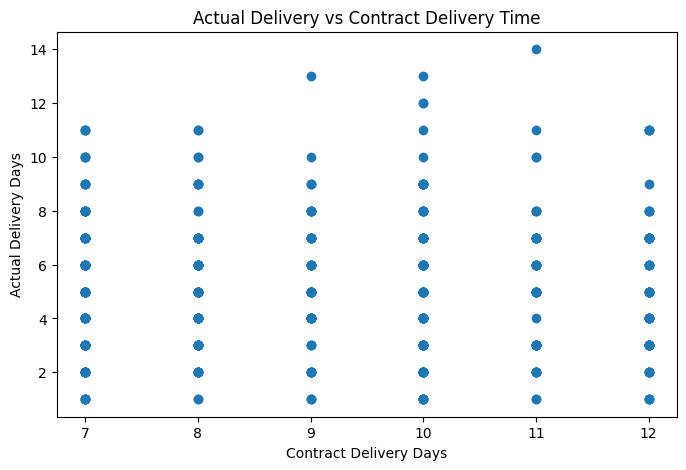

In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(
    final_output["Contract_Delivery_Days"],
    final_output["Actual_Delivery_Days"]
)

plt.title("Actual Delivery vs Contract Delivery Time")
plt.xlabel("Contract Delivery Days")
plt.ylabel("Actual Delivery Days")

plt.show()


In [24]:
print("===== DABA DAY 3 SUMMARY =====")

print("Total Shipments:", len(final_output))

print(
    "Contract Violations:",
    (final_output["Delivery_Compliance"] == "Violation").sum()
)

print(
    "Penalty Applicable:",
    (final_output["Penalty_Applicable"] == "Yes").sum()
)

print("\nContract Risk:")
print(final_output["Contract_Risk"].value_counts())

print("\nCompliance:")
print(final_output["Delivery_Compliance"].value_counts())


===== DABA DAY 3 SUMMARY =====
Total Shipments: 500
Contract Violations: 38
Penalty Applicable: 293

Contract Risk:
Contract_Risk
Low Risk       462
High Risk       27
Medium Risk     11
Name: count, dtype: int64

Compliance:
Delivery_Compliance
Compliant    462
Violation     38
Name: count, dtype: int64


In [25]:
final_output.to_csv(
    "day3_delay_contract_analysis.csv",
    index=False
)

print("✅ Day 3 CSV saved successfully!")




✅ Day 3 CSV saved successfully!


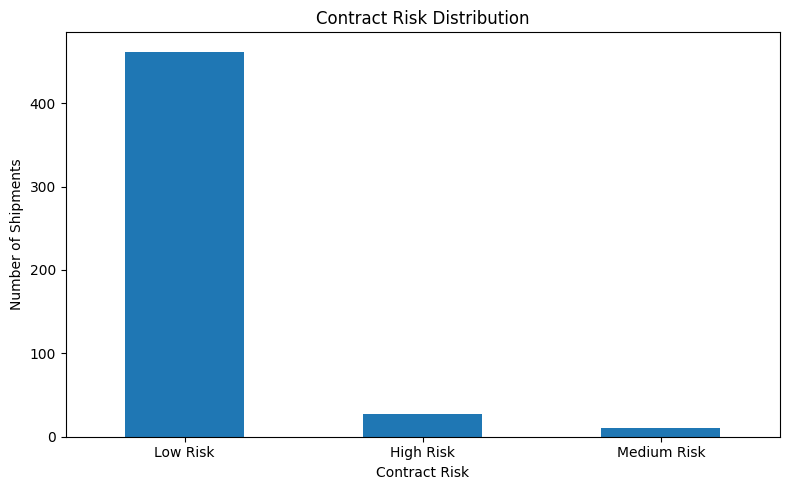

In [26]:
risk_counts = final_output["Contract_Risk"].value_counts()

plt.figure(figsize=(8, 5))
risk_counts.plot(kind="bar")
plt.title("Contract Risk Distribution")
plt.xlabel("Contract Risk")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("contract_risk_distribution.png", dpi=300)
plt.show()

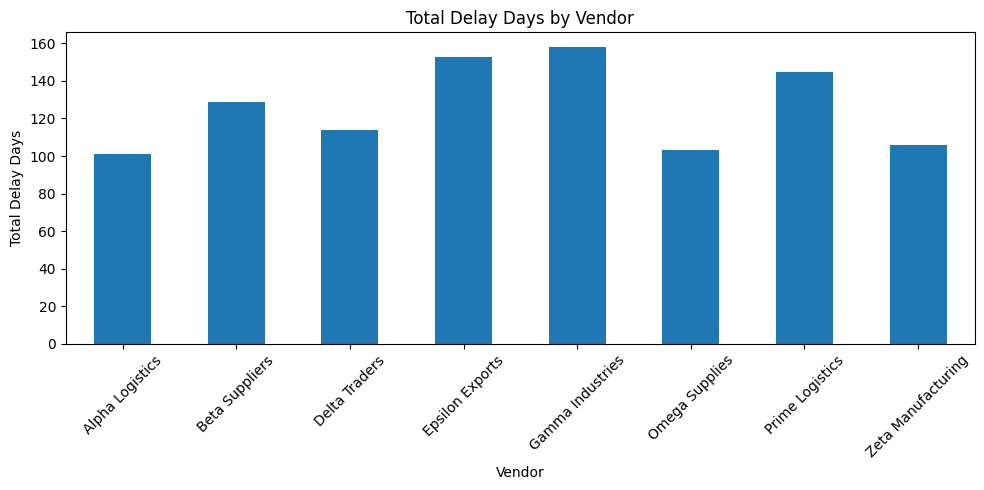

In [27]:
vendor_delay = final_output.groupby("Vendor")["Delay_Days"].sum()

plt.figure(figsize=(10, 5))
vendor_delay.plot(kind="bar")
plt.title("Total Delay Days by Vendor")
plt.xlabel("Vendor")
plt.ylabel("Total Delay Days")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("vendor_delay_analysis.png", dpi=300)
plt.show()

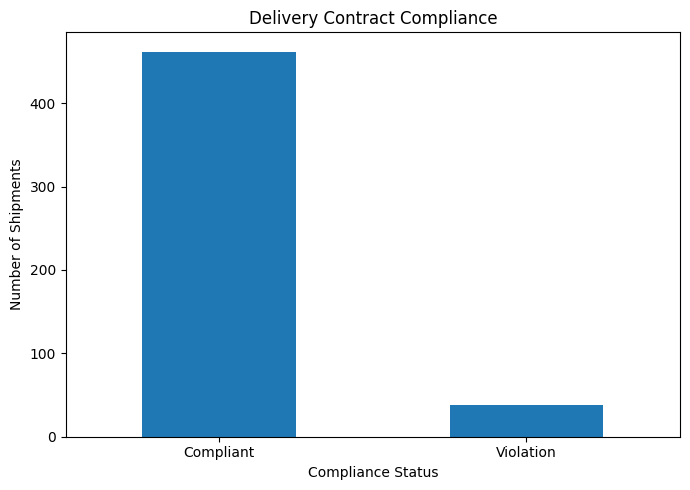

In [28]:
compliance_counts = final_output["Delivery_Compliance"].value_counts()

plt.figure(figsize=(7, 5))
compliance_counts.plot(kind="bar")
plt.title("Delivery Contract Compliance")
plt.xlabel("Compliance Status")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("delivery_compliance.png", dpi=300)
plt.show()

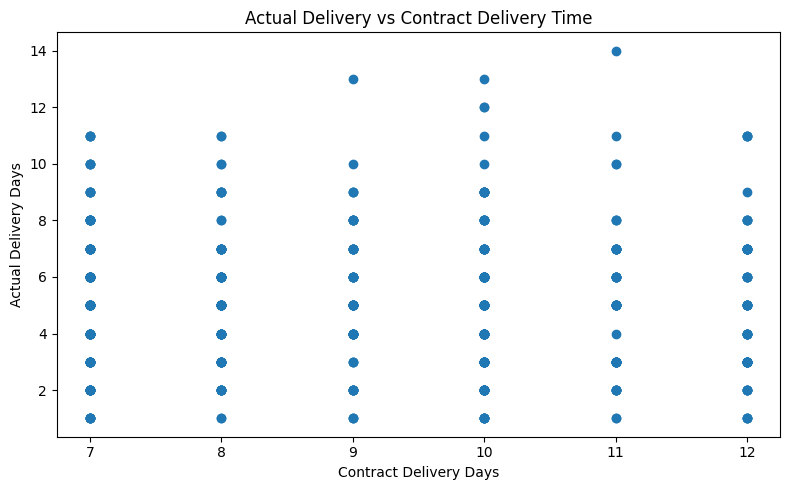

In [29]:
plt.figure(figsize=(8, 5))

plt.scatter(
    final_output["Contract_Delivery_Days"],
    final_output["Actual_Delivery_Days"]
)

plt.title("Actual Delivery vs Contract Delivery Time")
plt.xlabel("Contract Delivery Days")
plt.ylabel("Actual Delivery Days")

plt.tight_layout()
plt.savefig("actual_vs_contract_delivery.png", dpi=300)
plt.show()

In [30]:
from google.colab import files

files.download("day3_delay_contract_analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>